In [1]:
import requests
from IPython.core.display import HTML
HTML(f"""
<style>
</style>
""")

# Non-linear decision boundary
The following exercise experiments with a dataset (see visualization in the cell below), where a linear model cannot seperate the different classes in the data.

<article class="message">
    <div class="message-body">
        <strong>List of individual tasks</strong>
        <ul style="list-style: none;">
            <li>
            <a href="#linear">Task 1: Non-linear decision boundary</a>
            </li>
            <li>
            <a href="#manual">Task 2: Circular boundary</a>
            </li>
            <li>
            <a href="#predict2">Task 3: Predictions for non-linear data</a>
            </li>
            <li>
            <a href="#predict53">Task 4: Predictions for non-linear data</a>
            </li>
            <li>
            <a href="#polar">Task 5: Polar coordinates</a>
            </li>
        </ul>
    </div>
</article>

Run the cell below to load libraries and functions and construct the dataset:


In [ ]:
import numpy as np  # numerical computing
import matplotlib.pyplot as plt  # plotting core


def accuracy(predictions,targets):
    """
    :param predictions: 1D-array of predicted classes for the data.
    :param targets: 1D-array of actual classes for the data.
     
    :return: fraction of correctly predicted points (num_correct/num_points).
    """

    acc = np.sum(predictions == targets)/len(predictions)
    return acc

### Data generation
q1 = np.random.multivariate_normal([0, 0], [[.5, 0], [0, .5]], 400)

t = np.linspace(0, 2 * np.pi, 400)  ##  
q2 = np.array([(3 + q1[:, 0]) * np.sin(t), (3 + q1[:, 1]) * np.cos(t)]).T

The data of the two classes (`class 1`
 and `class 2`
) are stored in the variables `q1`
 and `q2`
, respectively. The following cell visualize the dataset of the two classes. `class 1`
 is labelled with 0s and `class 2`
 with 1s.


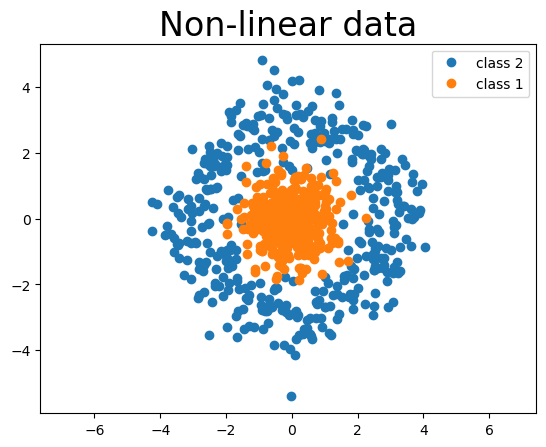

In [3]:
fig, ax = plt.subplots()
ax.plot(q2[:, 0], q2[:, 1], "o", label='class 2')
ax.plot(q1[:, 0], q1[:, 1], "o", label='class 1')

plt.title("Non-linear data", fontsize=24)
ax.axis('equal')
plt.legend()
plt.show()


---
**Task 1 (easy): Non-linear decision boundary👩‍💻💡**
The graph below shows how linear model performs on the current dataset (see last week
 ).
1. Using your observations about linear classification models, explain whether a linear classifier is an appropriate solution for the current data.
2. Which other models might provide a better fit to this dataset?


---

In [ ]:
# ------- 1 -----------
# A linear classification model will only make a straight line, and is not able to
# curve. Therefore it is not a very good fit for this circle of data.

# ------- 2 --------
# K-nearest neighbors would be an appropiate way of classifying this data, with
# the middle point in the middle of the circle, and the k and the distance metric
# is appropiate.


---
**Task 2 (easy): Circular boundary💡**
In this task the prediction function $f_w(x)$ is defined as a circular boundary centered in $[0,0]^T$.
1. Run the cell below to plot the circular boundary and the data points.
2. Change the radius of the decision boundary and determine which radius seems to best separate the classes?
3. Change the decision boundary and investigate how this affects the balance between false positives and false negatives? How does an overly large or small radius affect false positives and false negatives respectively? 


**Understanding the code**
The parametric equation of a circle, ([described in detail here](https://mathopenref.com/coordparamcircle.html)
) is given by:

$$
x = r \cos(t) \\
y = r \sin(t)
$$
where  $r$  is the radius of the circle and  $t$  represents angles (in radians) that range from  0  to  $2\pi$ .


---

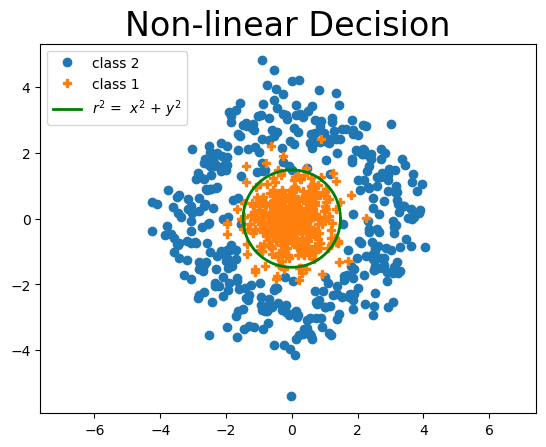

In [17]:
def circle_boundary(t, radius):
    """
    :param t: angle data points of the circle. 
    :param radius: radius of the circle
    :return: (x-values,y-values) of the circle points .
    """
    return (radius * np.cos(t), radius * np.sin(t))


fig, ax = plt.subplots()
ax.plot(q2[:, 0], q2[:, 1], "o", label='class 2')
ax.plot(q1[:, 0], q1[:, 1], "P", label='class 1')

t = np.linspace(0, 2 * np.pi, 400)  ### linspace of angles.
r = 1.48  # radius
x_c, y_c = circle_boundary(t, r)

ax.plot(x_c, y_c, "g",linewidth=2, label=r'$r^2$ =  $x^2$ + $y^2$')
plt.title("Non-linear Decision", fontsize=24)
ax.axis('equal')
plt.legend()
plt.show()

In [ ]:
# ------ 2 -------
# With a radius of about 1.8 seperates the points pretty consistenctly. But as can
# be seen it is not a perfect classification. There are some overlaps.

# --------- 3 ----------
# The smaller the radius gets, the bigger the amount of false negatives. 
# The bigger the radius gets, the bigger amount of false positives.
# (OBS. This is with the assumption of everything in the circle is positive, 
# however this is not specified.)



---
**Task 3 (easy): Predictions for non-linear data👩‍💻**
This task is about using the circular decision boundary (parametrized by $r$)  to classify points. Since the points are centered in $[0,0]^T$ the classification function should just check whether the distance of the point to the center is smaller or greater than $r$. That is  $\sqrt{x^2 + y^2}≤r$, or equivalently,  $x^2 + y^2 ≤ r^2$.
The prediction function is given by $f_w(x)= x^2 + y^2 - r^2$ as the decision function must fulfill $f_w(x) = 0$ on the decision boundary
1. Comple the `predict_circle`
 function. The function should take radius and data ($(x, y)$ coordinates) as inputs and return an array of predicted classes based on the decision function, e.g.:    
 - -1 for points where  $x^2 + y^2 < r^2$  (inside the circle).
 - 1 for points where  $x^2 + y^2 > r^2$  (outside the circle).


2. Use the `accuracy`
 function to get the fraction of correctly predicted data points.


---

In [18]:
def predict_circle(radius, data):
    """
    :param radius: radius of the circular decision boundary.
    :param data: Array containing data points to classify.
    
    :return: Array of predictions (-1 for inside, 1 for outside the boundary).
    """
    xs = data[:, 0]
    ys = data[:, 1]
    return np.sqrt(xs**2, ys**2) <= radius



pred_pos = predict_circle(r, q1)
pred_neg = predict_circle(r, q2)

acc_1 = accuracy(pred_pos, True)
acc_2 = accuracy(pred_neg, False)

print(f'A circular decision boundary with radius: {r:1}, has an accuracy of: {(acc_1+acc_2)/2:.3f}')

A circular decision boundary with radius: 1.48, has an accuracy of: 0.810



---
**Task 4 (easy): Predictions for non-linear data💡📽️**
In the cell below, reflect on:
1. Visually what is the optimal choice for radius of the classifier?
2. Try 10 different radius values and identify which one results in the highest accuracy.
3. How does the type of the data influence the choice of "optimality"? 


---

In [0]:
# --------- 1 ----------
# visually it should be just under 2. This lays in between the overlay of the two
# classes.

# -------- 2 -----------
# After ten tries, the closest accuracy i could get was 0.810, bu using the radius
# of 1.48

# ---------- 3 -----------
# It very much influcences the choice of "optimality" what kind of data we are
# working with.
# For example we should be pretty sure to not have false positives
# in some applications, false positives are very costly and must be minimized.
# This is in things like:
        # Criminal justice / court decisions (do not accuse innocent people)
        # Loan or credit approval systems

# In other applications, false negatives are more costly and should be minimized.
# Examples where we want to avoid false negatives:
        # Fraud detection (do not miss actual fraud)
        # Medical screening (do not miss sick patients)
        # Safety-critical fault detection

## Non-linear transformations to the data using polar coordinates
This task is about applying non-linear transformations to facilitate the use of a linear classifier. A point can be represented either by its Cartesian coordinates,  $x$, $y$ , or equivalently by its polar coordinates, defined by an angle $\theta$ and distance $r$ from the origin as shown in [Figure 1](#tensorboard). 
<div class="has-text-centered">
<figure class="image is-inline-block" id="tensorboard">

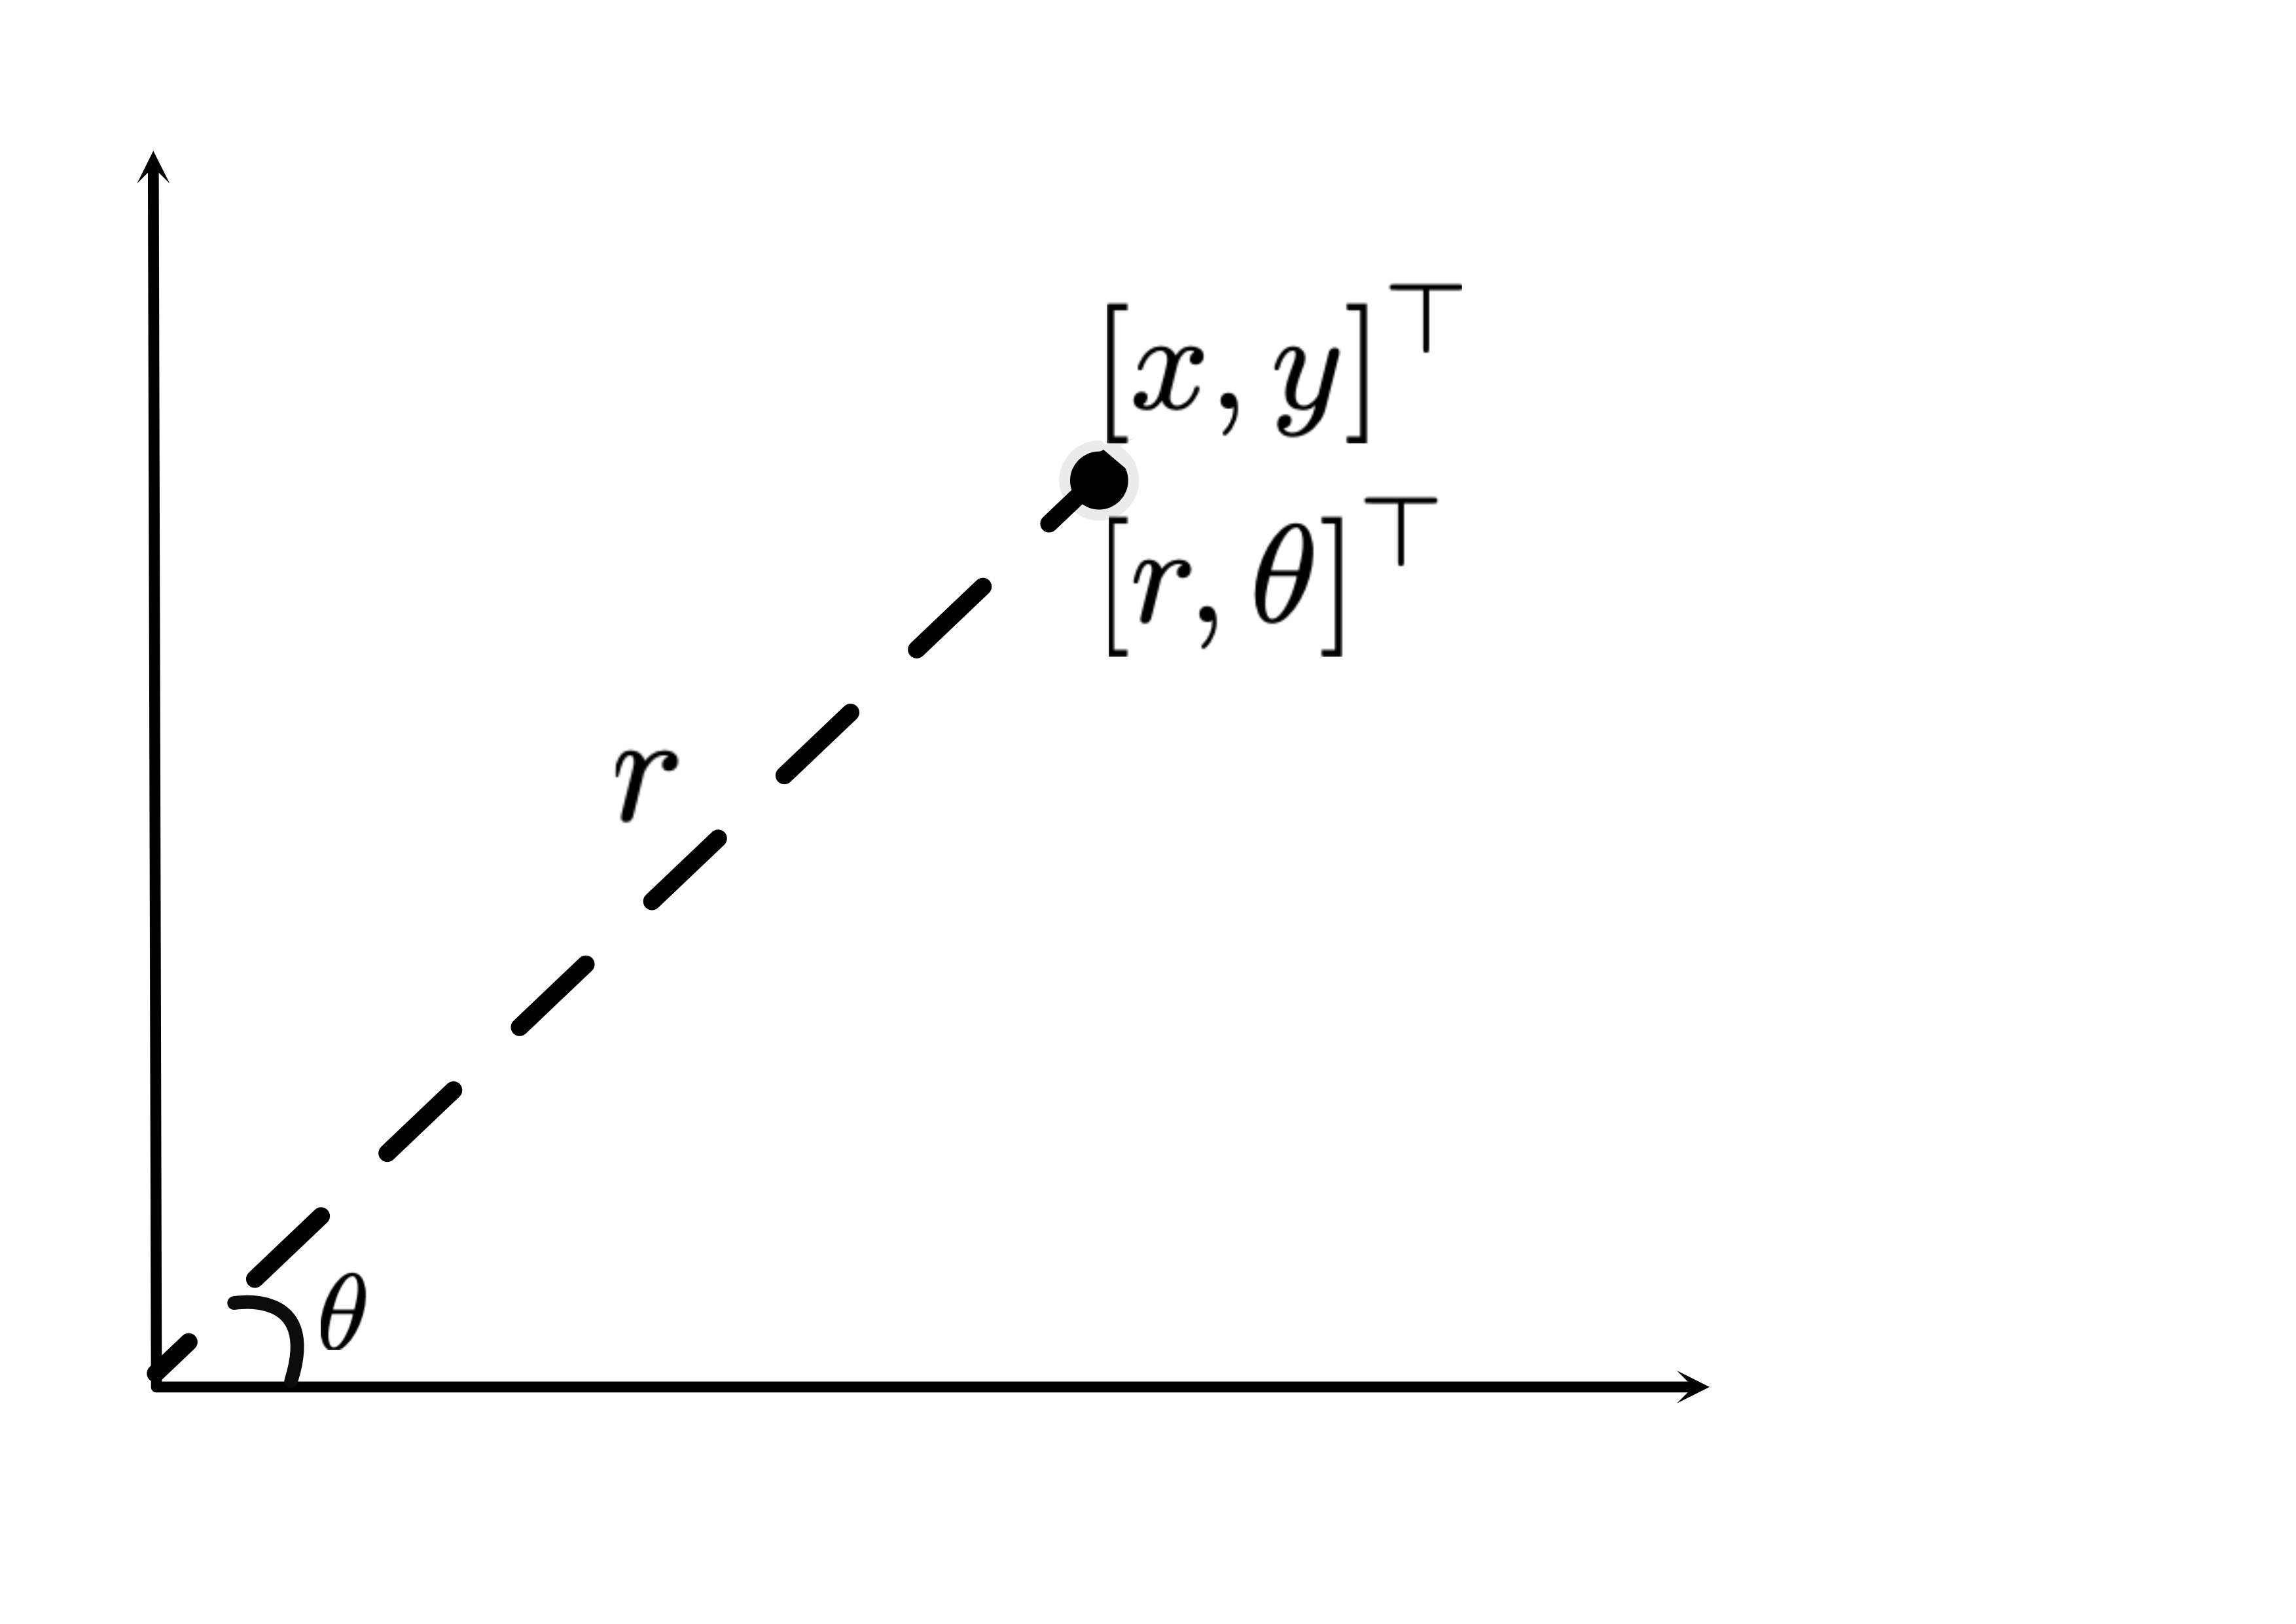

<figcaption class="figure-caption has-text-centered">Figure 1</figcaption>
</figure>
</div>

---
**Task 5 (easy): Polar coordinates👩‍💻💡📽️**
The function `map_to_polar_separable`
 below non-linearly transforms each point $(x, y)$ to its polar coordinates $(r, \theta)$.
1. Run the cell below to visualize the dataset in polar coordinates. 
2. Compare the distribution of the data in polar versus Cartesian coordinates. What key differences do you observe?
3. Does transforming the data to polar coordinates make it easier to separate the classes with a linear classifier? How does this transformation change the classification problem?
4. Which parameter separates the classes?
5. Reflect on how pre-processing of data can change the models used for classification.
6. How is the non-linear transformation to polar coordinates different from using kernels for classification?


---

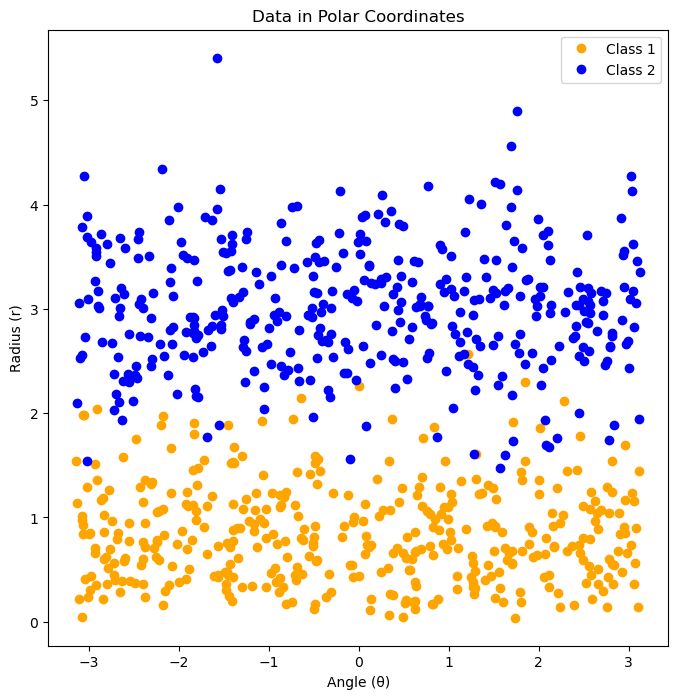

In [19]:
def map_to_polar_separable(data):
    """
    Maps circular data centered at (0, 0) to polar coordinates (r, theta),
    making the data linearly separable by radius (r).
 
    Parameters:
    - data: A numpy array of shape (N, 2) where each row is a point (x, y).
 
    Returns:
    - polar_data: A numpy array of shape (N, 2) where each row is (r, theta),
      where r is the radial distance and theta is the angle in radians.
    """
    # Convert to polar coordinates
    r = np.sqrt(data[:, 0]**2 + data[:, 1]**2)  # Radial distance
    theta = np.arctan2(data[:, 1], data[:, 0])  # Angle in radians
   
    # Stack r and theta to form polar data
    polar_data = np.column_stack((r, theta))
   
    return polar_data
   
data = np.vstack([q1, q2])  
polar_data=map_to_polar_separable(data)

# Split polar data into classes
polar_q1 = polar_data[:len(q1)]
polar_q2 = polar_data[len(q1):]

# Plot data in polar coordinates
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(polar_q1[:, 1], polar_q1[:, 0], "o", label="Class 1", color="orange")
ax.plot(polar_q2[:, 1], polar_q2[:, 0], "o", label="Class 2", color="blue")
plt.xlabel("Angle (θ)")
plt.ylabel("Radius (r)")
plt.title("Data in Polar Coordinates")
plt.legend()
plt.show()

In [0]:
# ------ 2 --------
# We can see that it is no longer actually a circle, but instead seperated into
# the different radiuses in height.
# And we also observe that a linear model could actually classify this data!

# ------- 3 ---------
# Yes in this case it made it easier to classify these points, due to us not
# having to make a circle, but actually being able to use a linear model to classify
# it. It is also significantly easier to spot where the line should be, compared 
# to the circle.

# ------- 4 --------
# As before it is still the radius that is the parameter that seperates the classes.

# ------- 5 --------
# This task is a good example of how pre-processing allows for easier classification.
# For example in this task, the easiest way to classify this is in polar coordinates,
# and therefore if we had the opportunity to either save pre-process the points in
# either (x,y) coordinates or polar, we now it is easiest with polar coordinates.

# --------- 6 ----------
# With polar coordinates, we manually change the data before training.
# With kernels, the model automatically handles the non-linear separation without explicitly changing the data.


